In [2]:
import h5py
import json
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch

from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet_repro.paths import preprocessed_datasets
from methylseqnet.metrics import pearson_per_task, fisher_mean

In [3]:
atlas_folder = preprocessed_datasets / "atlas"
gm12878_haplotyped_folder = preprocessed_datasets / "gm12878_haplotyped"

checkpoints = {
    "Borzoi-0 pretrained + 8M FaRM conditioned, run imputed":"slurm32260895task0/fold3_truecondweight_0.0",
    "Borzoi-0 pretrained + 8M FaRM conditioned":"slurm32260895task0/fold3",
    "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned":"slurm32260895task1/fold3",
    "Borzoi-0 pretrained + 8M concatenation conditioned":"slurm32260895task2/fold3",
    "Borzoi-0 pretrained + 8M FiLM conditioned":"slurm32260895task3/fold3",
    "Borzoi-0 pretrained + 124K probe unconditioned":"slurm32273742task4/fold3",
    "Basenji2 reinitialized + 10M FaRM conditioned":"slurm32260895task5/fold3",
    "Basenji2 reinitialized + 10M imputed-FaRM unconditioned":"slurm32260895task6/fold3",
    "Borzoi-1 pretrained + 8M FaRM conditioned":"slurm32260895task7/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned, atlas only":"slurm32260895task8/fold3",
    "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned, atlas only":"slurm32260895task9/fold3",
    "Borzoi-0 pretrained + 27M FaRM conditioned":"slurm32260895task10/fold3",
    "Borzoi-0 pretrained + 27M imputed-FaRM unconditioned":"slurm32260895task11/fold3",
    "Basenji2 pretrained + 10M FaRM conditioned":"slurm32260926task12/fold3",
    "Basenji2 pretrained + 10M imputed-FaRM unconditioned":"slurm32260926task13/fold3",
    "Borzoi-2 pretrained + 8M FaRM conditioned":"slurm32263095task14/fold3",
    "Borzoi-3 pretrained + 8M FaRM conditioned":"slurm32263095task15/fold3",
    "Borzoi-0 pretrained + 1M FaRM conditioned":"slurm32263095task16/fold3",
    "Borzoi-0 pretrained + 2.5M FaRM conditioned":"slurm32263095task17/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned transformer 4x256":"slurm32263095task18/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned transformer 8x128":"slurm32263095task19/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 1 dilated layer":"slurm32263095task20/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 3 dilated layers":"slurm32263095task21/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 7 dilated layers":"slurm32263095task22/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 1:15 cond:uncond":"slurm32263095task23/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 1:3 cond:uncond":"slurm32263095task24/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 3:1 cond:uncond":"slurm32263095task25/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned 15:1 cond:uncond":"slurm32263095task26/fold3",
    "100K CNN one-hot encoded":"slurm32263821task27/fold3",
    "100K CNN interpolated encoding":"slurm32263821task28/fold3",
    "100K CNN 0.1kbp smoothing":"slurm32263821task29/fold3",
    "Borzoi-0 pretrained + 8M FaRM conditioned, long-read only":"slurm32265241task30/fold3",
    "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned, long-read only":"slurm32265241task31/fold3",
    "100K CNN 1kbp smoothing":"slurm32292528task32/fold3",
    "100K CNN 8kbp smoothing":"slurm32292528task33/fold3",
    "100K CNN sequence only":"slurm32292528task34/fold3",
    "100K CNN methyl only":"slurm32293065task35/fold3",
    "Borzoi-0 pretrained + 8M unconditioned unimputed":"slurm32603230task36/fold3",
}
def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str):
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch

In [ ]:
# from pathlib import Path
# import shutil
# from methylseqnet.model import ConditionedSeqNN
# from methylseqnet_repro.paths import model_checkpoints
# # move checkpoints 
# for checkpoint_label, checkpoint_with_fold in checkpoints.items():
#     checkpoint_id = checkpoint_with_fold.split("/")[0]
#     best_ckpt = max(
#             Path(model_checkpoints / checkpoint_id / "checkpoints").glob('best*.ckpt'),
#             key=lambda p: p.stat().st_mtime
#         )
#     checkpoint = torch.load(best_ckpt, map_location=torch.device('cpu'))
#     model_gin_config = checkpoint["operative_config_str"]
#     new_path = Path("/global/scratch/projects/vector_streetslab/oberon/methylseq-net-reproducibility/checkpoints/") / checkpoint_id
#     new_path.mkdir(parents=True, exist_ok=True)
#     with open(new_path / "description.txt", "w") as f:
#         f.write(checkpoint_label)
#         f.write("\n\n")
#         f.write(model_gin_config)
#     new_checkpoints_path = new_path / "checkpoints"
#     new_checkpoints_path.mkdir(exist_ok=True)
#     shutil.copy2(src=best_ckpt, dst=new_checkpoints_path / best_ckpt.name)


In [3]:
def plot_metrics(
    metrics_dict: dict[str, dict[str, float]],
    models: list[str] | None = None,
    metrics: list[str] | None = None,
    figsize: tuple[float, float] = (10, 6),
    title: str | None = None,
    ylabel: str | None = None,
    bar_width: float = 0.8,
    ax: plt.Axes | None = None,
    colors: list[str] | None = None,
    hatches: list[str | None] | None = None,
    edgecolors: list[str] | None = None,
):
    """Grouped bar plot: groups = metrics, bars within group = models.

    Parameters
    ----------
    metrics_dict : dict[str, dict[str, float]]
        {model_description: {metric_name: value, ...}, ...}
    models : list[str], optional
        Subset / ordering of model keys to plot. Defaults to all.
    metrics : list[str], optional
        Subset / ordering of metric names to plot. Defaults to all
        metrics present across the selected models.
    """
    # Resolve models and metrics
    if models is None:
        models = list(metrics_dict.keys())
    if metrics is None:
        seen = dict()  # preserves insertion order, deduplicates
        for m in models:
            for k in metrics_dict[m]:
                seen[k] = None
        metrics = list(seen)

    n_models = len(models)
    n_metrics = len(metrics)
    single_width = bar_width / n_models
    x = np.arange(n_metrics)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if colors is not None and len(colors) != n_models:
        raise ValueError(f"len(colors)={len(colors)} must match len(models)={n_models}")
    
    if hatches is not None and len(hatches) != n_models:
        raise ValueError(f"len(hatches)={len(hatches)} must match len(models)={n_models}")

    if edgecolors is not None and len(edgecolors) != n_models:
        raise ValueError(f"len(edgecolors)={len(edgecolors)} must match len(models)={n_models}")
    
    if colors is None:
        cmap = plt.cm.get_cmap("tab10") if n_models <= 10 else plt.cm.get_cmap("tab20")
        colors = [cmap(i) for i in range(n_models)]

    for i, model in enumerate(models):
        offsets = x - bar_width / 2 + single_width * (i + 0.5)
        values = [np.mean(metrics_dict[model].get(metric, 0.0)) for metric in metrics]
        ci_lo = [np.percentile(metrics_dict[model].get(metric, [0.0]), 2.5) for metric in metrics]
        ci_hi = [np.percentile(metrics_dict[model].get(metric, [0.0]), 97.5) for metric in metrics]
        yerr = [
            [m - lo for m, lo in zip(values, ci_lo)],
            [hi - m for m, hi in zip(values, ci_hi)],
        ]
        ax.bar(offsets, values, width=single_width, label=model, color=colors[i],
            hatch=hatches[i] if hatches is not None else None,
            edgecolor=edgecolors[i] if edgecolors is not None else None,
            yerr=yerr, capsize=2, error_kw={"linewidth": 0.8})

    ax.set_xticks(x)
    ax.set_xticklabels([metric.replace('\nPearson correlation','') for metric in metrics], rotation=0, ha="center", fontsize=8)
    ax.legend(title="Model", fontsize=8)
    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    fig.tight_layout()
    return fig, ax

In [4]:
# metrics_dict = {
#     model_description: {} for model_description in checkpoints.keys()
# }
# calculate_metrics = True
# num_bootstrapping_trials = 100

# for description, checkpoint in tqdm(checkpoints.items(), desc="Evaluating checkpoints"):
#     atlas_h5_file = atlas_folder / checkpoint / "predictions.h5"
#     gm_h5_file = gm12878_haplotyped_folder / checkpoint / "predictions.h5"
#     for dataset_key, h5_file in [("atlas", atlas_h5_file), ("longread", gm_h5_file)]:
#         try:
#             dataset = BaseHDF5Dataset(
#                 h5_file,
#                 datasets = {"predictions", "tracks"},
#                 return_specifiers = True,
#             )
#             # assert len(dataloader.dataset) == 6888, f"Expected 6888 samples in the dataset, but got {len(dataloader.dataset)}"
#             io_mappings_df = dataset.get_io_mappings_df()
#             if calculate_metrics:
#                 device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#                 with h5py.File(h5_file, "r") as h5f:
#                     predictions_by_sample = torch.tensor(h5f["predictions"][:]).to(device)
#                     tracks_by_sample = torch.tensor(h5f["tracks"][:]).to(device)
#                     chroms_list = [specifier.decode(encoding="utf-8", errors="strict").split("|")[0].split(":")[0] for specifier in h5f["specifier"][:]]

#                 match dataset_key:
#                     case "atlas":
#                         predictions = predictions_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#                         tracks = tracks_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)

#                         atac_channels = io_mappings_df[io_mappings_df["data_type"] == "ATAC-seq"]["channel"].tolist()
#                         cage_channels = io_mappings_df[io_mappings_df["data_type"] == "CAGE-seq"]["channel"].tolist()
                        
#                         atac_tracks = tracks[:, atac_channels, :].squeeze()
#                         cage_tracks = tracks[:, cage_channels, :].squeeze()
#                         mean_subtracted_atac_tracks = atac_tracks - atac_tracks.mean(dim=0, keepdim=True)
#                         mean_subtracted_cage_tracks = cage_tracks - cage_tracks.mean(dim=0, keepdim=True)
                        
#                         atac_predictions = predictions[:, atac_channels, :].squeeze()
#                         cage_predictions = predictions[:, cage_channels, :].squeeze()
#                         mean_subtracted_atac_predictions = atac_predictions - atac_predictions.mean(dim=0, keepdim=True)
#                         mean_subtracted_cage_predictions = cage_predictions - cage_predictions.mean(dim=0, keepdim=True)
                        
#                         atac_pearsons_by_task = [
#                             pearson_per_task(
#                                 predictions = atac_predictions[..., idx],
#                                 targets = atac_tracks[..., idx],
#                             )
#                             for _ in range(num_bootstrapping_trials)
#                             for idx in [torch.randint(0, atac_tracks.shape[-1], (atac_tracks.shape[-1],),device=device)]
#                         ]

#                         cage_pearsons_by_task = [
#                             pearson_per_task(
#                                 predictions = cage_predictions[..., idx],
#                                 targets = cage_tracks[..., idx],
#                             )
#                             for _ in range(num_bootstrapping_trials)
#                             for idx in [torch.randint(0, cage_tracks.shape[-1], (cage_tracks.shape[-1],),device=device)]
#                         ]
#                         mean_subtracteds_atac_pearson_by_task = [
#                             pearson_per_task(
#                                 predictions = mean_subtracted_atac_predictions[..., idx],
#                                 targets = mean_subtracted_atac_tracks[..., idx],
#                             )
#                             for _ in range(num_bootstrapping_trials)
#                             for idx in [torch.randint(0, mean_subtracted_atac_tracks.shape[-1], (mean_subtracted_atac_tracks.shape[-1],),device=device)]
#                         ]
#                         mean_subtracteds_cage_pearson_by_task = [
#                             pearson_per_task(
#                                 predictions = mean_subtracted_cage_predictions[..., idx],
#                                 targets = mean_subtracted_cage_tracks[..., idx],
#                             )
#                             for _ in range(num_bootstrapping_trials)
#                             for idx in [torch.randint(0, mean_subtracted_cage_tracks.shape[-1], (mean_subtracted_cage_tracks.shape[-1],),device=device)]
#                         ]
#                         metrics_dict[description][f"ATAC-seq\nPearson correlation"] = [
#                             fisher_mean(atac_pearson_by_task)
#                             for atac_pearson_by_task in atac_pearsons_by_task
#                         ]
#                         metrics_dict[description][f"CAGE-seq\nPearson correlation"] = [
#                             fisher_mean(cage_pearson_by_task)
#                             for cage_pearson_by_task in cage_pearsons_by_task
#                         ]
#                         metrics_dict[description][f"Cell-type-differential ATAC-seq\nPearson correlation"] = [
#                             fisher_mean(mean_subtracted_atac_pearson_by_task)
#                             for mean_subtracted_atac_pearson_by_task in mean_subtracteds_atac_pearson_by_task
#                         ]
#                         metrics_dict[description][f"Cell-type-differential CAGE-seq\nPearson correlation"] = [
#                             fisher_mean(mean_subtracted_cage_pearson_by_task)
#                             for mean_subtracted_cage_pearson_by_task in mean_subtracteds_cage_pearson_by_task
#                         ]
#                     case "longread":
#                         chrX_indices = [i for i, chrom in enumerate(chroms_list) if chrom == "chrX"]
#                         autosome_indices = [i for i, chrom in enumerate(chroms_list) if chrom != "chrX"]

#                         predictions = predictions_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#                         predictions_chrX = predictions_by_sample[chrX_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#                         predictions_autosomes = predictions_by_sample[autosome_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
                        
#                         tracks = tracks_by_sample.permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#                         tracks_chrX = tracks_by_sample[chrX_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)
#                         tracks_autosomes = tracks_by_sample[autosome_indices].permute(1, 2, 3, 0).flatten(start_dim=2, end_dim=3)

#                         fiber_channels = io_mappings_df[io_mappings_df["data_type"] == "Fiber-seq"]["channel"].tolist()
#                         rna_channels = io_mappings_df[io_mappings_df["data_type"] == "RNA-seq"]["channel"].tolist()
                        
#                         for subset_name, subset_predictions, subset_tracks in [
#                             (chrX", predictions_chrX, tracks_chrX),
#                             ("Autosomes", predictions_autosomes, tracks_autosomes),
#                             ("All chr.", predictions, tracks),]:
                        
#                             fiber_tracks = subset_tracks[:, fiber_channels, :][0]
#                             rna_tracks = subset_tracks[:, rna_channels, :][0]
#                             differential_tracks = subset_tracks[0,...] - subset_tracks[1,...]
#                             differential_fiber_tracks = differential_tracks[fiber_channels, :]
#                             differential_rna_tracks = differential_tracks[rna_channels, :]

#                             fiber_predictions = subset_predictions[:, fiber_channels, :][0]
#                             rna_predictions = subset_predictions[:, rna_channels, :][0]
#                             differential_predictions = subset_predictions[0,...] - subset_predictions[1,...]
#                             differential_fiber_predictions = differential_predictions[fiber_channels, :]
#                             differential_rna_predictions = differential_predictions[rna_channels, :]
                            
#                             fiber_pearson_by_task = [
#                                 pearson_per_task(
#                                     predictions = fiber_predictions[..., idx],
#                                     targets = fiber_tracks[..., idx],
#                                 )
#                                 for _ in range(num_bootstrapping_trials)
#                                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],),device=device)]
#                             ]
#                             rna_pearson_by_task = [
#                                 pearson_per_task(
#                                     predictions = rna_predictions[..., idx],
#                                     targets = rna_tracks[..., idx],
#                                 )
#                                 for _ in range(num_bootstrapping_trials)
#                                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],),device=device)]
#                             ]
#                             differential_fiber_pearson_by_task = [
#                                 pearson_per_task(
#                                     predictions = differential_fiber_predictions[..., idx],
#                                     targets = differential_fiber_tracks[..., idx],
#                                 )
#                                 for _ in range(num_bootstrapping_trials)
#                                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],),device=device)]
#                             ]
#                             differential_rna_pearson_by_task = [
#                                 pearson_per_task(
#                                     predictions = differential_rna_predictions[..., idx],
#                                     targets = differential_rna_tracks[..., idx],
#                                 )
#                                 for _ in range(num_bootstrapping_trials)
#                                 for idx in [torch.randint(0, fiber_tracks.shape[-1], (fiber_tracks.shape[-1],),device=device)]
#                             ]
#                             metrics_dict[description][f"{subset_name}\nFiber-seq\nPearson correlation"] = [
#                                 fisher_mean(fiber_pearson_by_task)
#                                 for fiber_pearson_by_task in fiber_pearson_by_task
#                             ]
#                             metrics_dict[description][f"{subset_name}\nIso-seq 5'\nPearson correlation"] = [
#                                 fisher_mean(rna_pearson_by_task)
#                                 for rna_pearson_by_task in rna_pearson_by_task
#                             ]
#                             metrics_dict[description][f"{subset_name} Haplotype-differential\nFiber-seq\nPearson correlation"] = [
#                                 fisher_mean(differential_fiber_pearson_by_task)
#                                 for differential_fiber_pearson_by_task in differential_fiber_pearson_by_task
#                             ]
#                             metrics_dict[description][f"{subset_name} Haplotype-differential\nIso-seq 5'\nPearson correlation"] = [
#                                 fisher_mean(differential_rna_pearson_by_task)
#                                 for differential_rna_pearson_by_task in differential_rna_pearson_by_task
#                             ]
#                     case _:
#                         raise ValueError(f"Unknown dataset key: {dataset_key}")

#         except (ValueError, OSError) as e:
#             print(f"{dataset_key}: checkpoint {checkpoint} not successfully opened.")

In [5]:
# with open("metrics.json", "w") as f:
#     json.dump(metrics_dict, f, indent=4)
with open("metrics.json", "r") as f:
    metrics_dict = json.load(f)
metrics_dict["Conditioned"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Unconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M imputed-FaRM unconditioned"]
metrics_dict["Methylation-conditioned sequence embedding"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Unconditioned sequence embedding only"] = metrics_dict["Borzoi-0 pretrained + 8M imputed-FaRM unconditioned"]
metrics_dict["Methylation-only small CNN"] = metrics_dict["100K CNN methyl only"]
metrics_dict["FiLM"] = metrics_dict["Borzoi-0 pretrained + 8M FiLM conditioned"]
metrics_dict["FaRM"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Concatenation"] = metrics_dict["Borzoi-0 pretrained + 8M concatenation conditioned"]
metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned 5 dilated layers"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned 1:1 cond:uncond"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Total features 1024 (8M FaRM parameters)"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Total features 256 (1M FaRM parameters)"] = metrics_dict["Borzoi-0 pretrained + 1M FaRM conditioned"]
metrics_dict["Total features 512 (2.5M FaRM parameters)"] = metrics_dict["Borzoi-0 pretrained + 2.5M FaRM conditioned"]
metrics_dict["Total feature 2048 (27M FaRM parameters)"] = metrics_dict["Borzoi-0 pretrained + 27M FaRM conditioned"]
metrics_dict["Replicate 0"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Replicate 1"] = metrics_dict["Borzoi-1 pretrained + 8M FaRM conditioned"]
metrics_dict["Replicate 2"] = metrics_dict["Borzoi-2 pretrained + 8M FaRM conditioned"]
metrics_dict["Replicate 3"] = metrics_dict["Borzoi-3 pretrained + 8M FaRM conditioned"]
metrics_dict["Basenji2 pretrained"] = metrics_dict["Basenji2 pretrained + 10M FaRM conditioned"]
metrics_dict["Basenji2 from scratch"] = metrics_dict["Basenji2 reinitialized + 10M FaRM conditioned"]
metrics_dict["Borzoi pretrained"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Allelic imbalance\nconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M imputed-FaRM unconditioned, long-read only"]
metrics_dict["Cell types\nconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned, atlas only"]
metrics_dict["Allelic imbalance and\ncell types, conditioned"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned"]
metrics_dict["Allelic imbalance\nunconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M FaRM conditioned, long-read only"]
metrics_dict["Cell types\nunconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M imputed-FaRM unconditioned, atlas only"]
metrics_dict["Allelic imbalance and\ncell types, unconditioned"] = metrics_dict["Borzoi-0 pretrained + 8M imputed-FaRM unconditioned"]
metrics_dict["100K CNN one-hot encoded methylation" ] = metrics_dict["100K CNN one-hot encoded"]


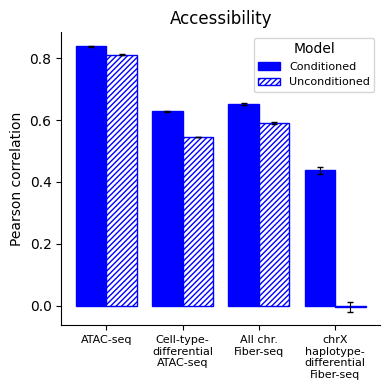

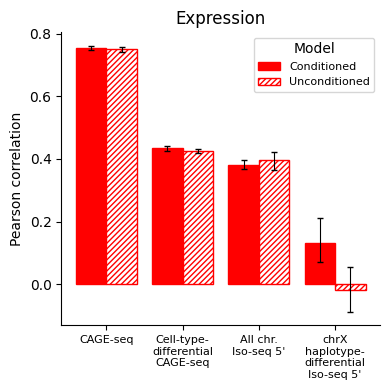

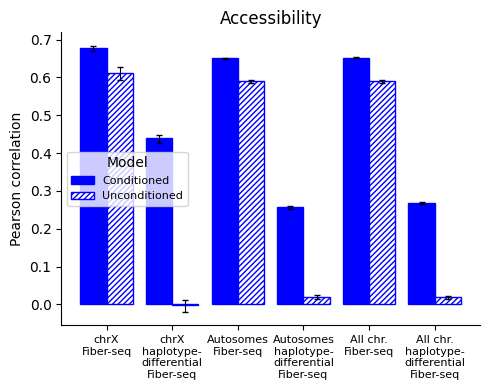

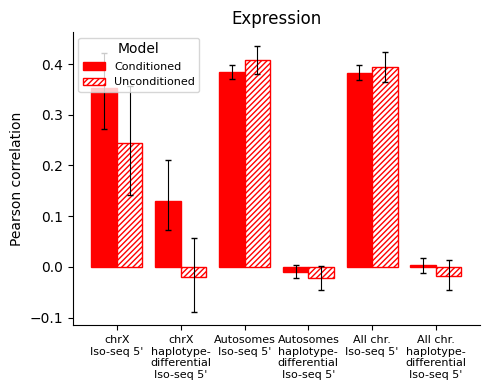

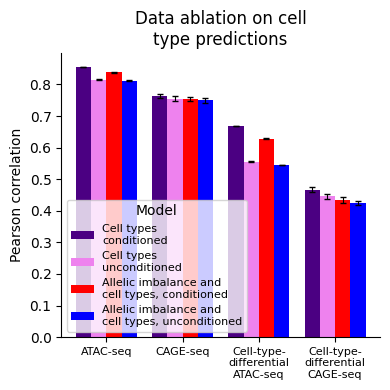

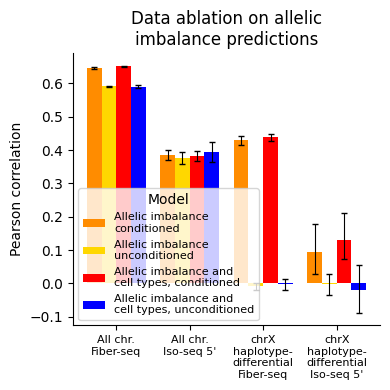

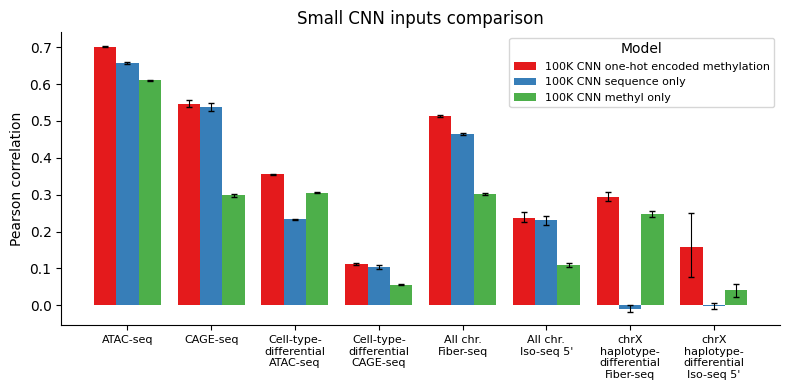

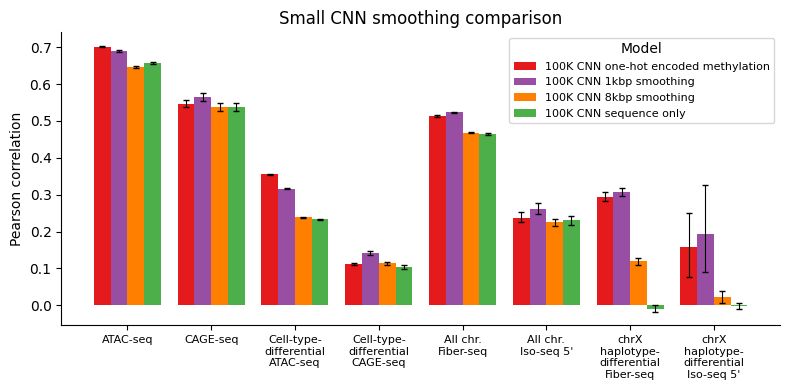

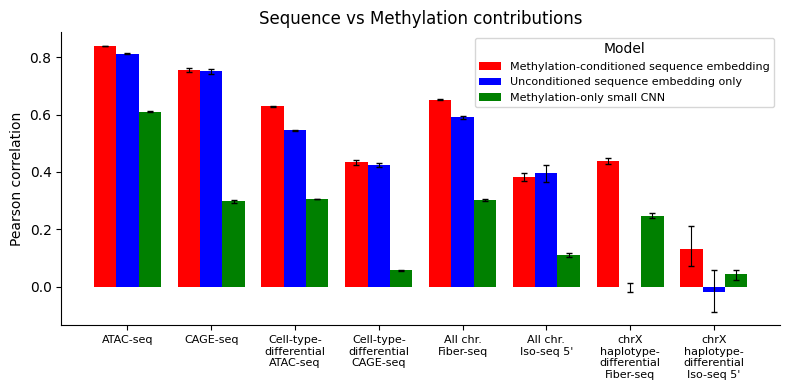

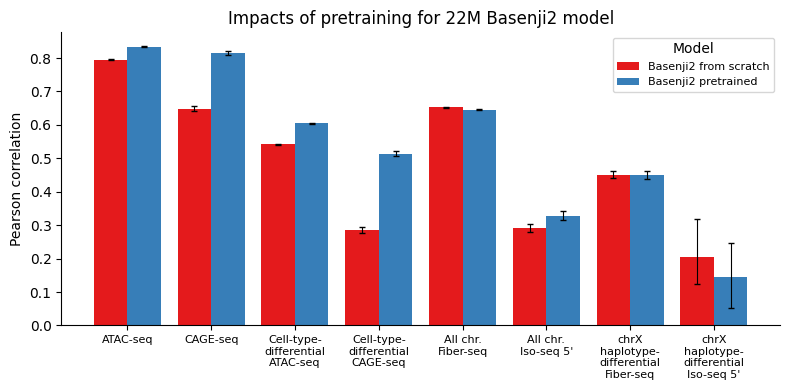

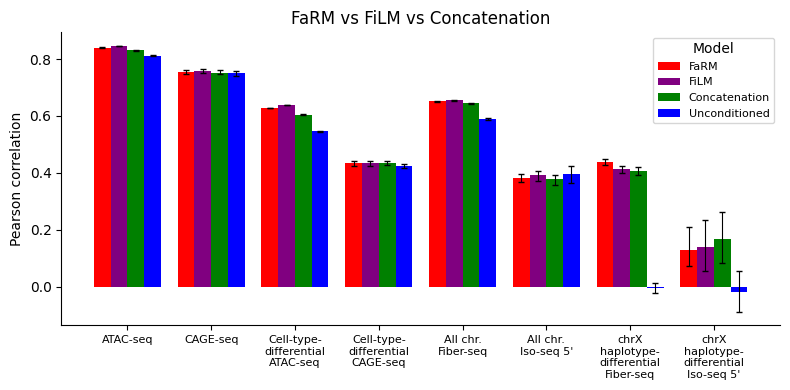

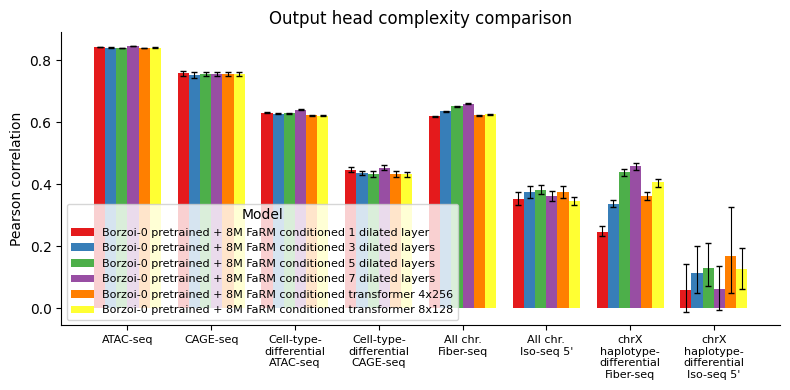

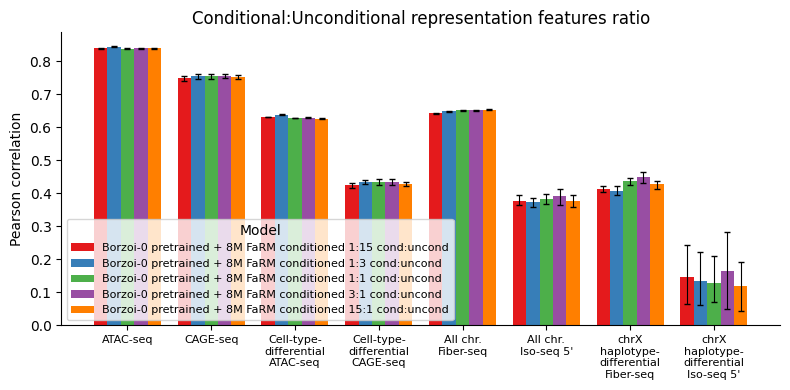

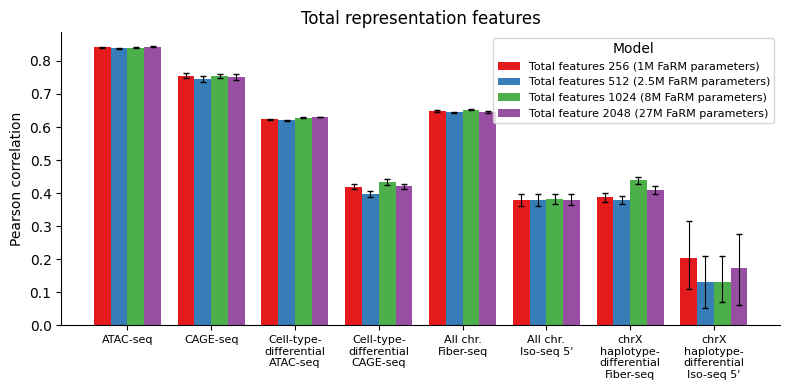

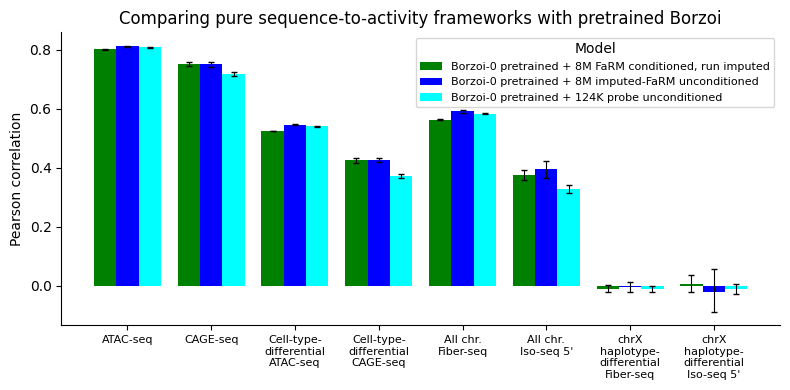

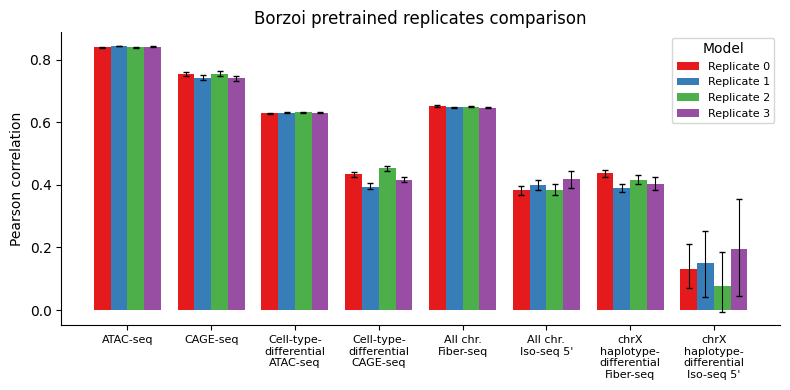

In [6]:
all_metrics = list(list(metrics_dict.values())[0].keys())
all_descriptions = list(metrics_dict.keys())
shortread_subset = [metric for metric in all_metrics if ("ATAC" in metric or "CAGE" in metric)]
longread_subset = [
    metric for metric in all_metrics if (
        ("Fiber" in metric or "Iso" in metric)
        and ("All chr" in metric and "aplotype" not in metric)
    )
] + [
    metric for metric in all_metrics if (
        ("Fiber" in metric or "Iso" in metric)
        and ("chrX" in metric and "aplotype" in metric)
    )
]
accessibility_subset = [metric for metric in all_metrics if "ATAC" in metric] + [metric for metric in longread_subset if "Fiber" in metric]
expression_subset = [metric for metric in all_metrics if "CAGE" in metric] + [metric for metric in longread_subset if "Iso" in metric]
all_fiber = [metric for metric in all_metrics if "Fiber" in metric]
all_rna = [metric for metric in all_metrics if "Iso" in metric]
cmap = plt.get_cmap('Set1')  # 10 distinct colors
for title, description_subset, colors, hatches, edgecolors, metrics_subset, figsize, savename in [
    (
        "Accessibility",
        ["Conditioned", "Unconditioned"],
        ["blue", "white"],
        ["","//////"],
        ["blue", "blue"],
        accessibility_subset,
        (4, 4),
        "overview__accessibility",
    ),
    (
        "Expression",
        ["Conditioned", "Unconditioned"],
        ["red", "white"],
        ["","//////"],
        ["red", "red"],
        expression_subset,
        (4, 4),
        "overview__expression",
    ),
    (
        "Accessibility",
        ["Conditioned", "Unconditioned"],
        ["blue", "white"],
        ["","//////"],
        ["blue", "blue"],
        all_fiber,
        (5, 4),
        "allelic_imbalance__accessibility",
    ),
    (
        "Expression",
        ["Conditioned", "Unconditioned"],
        ["red", "white"],
        ["","//////"],
        ["red", "red"],
        all_rna,
        (5, 4),
        "allelic_imbalance__expression",
    ),
    (
        "Data ablation on cell\ntype predictions",
        ["Cell types\nconditioned","Cell types\nunconditioned","Allelic imbalance and\ncell types, conditioned","Allelic imbalance and\ncell types, unconditioned"],
        ["indigo","violet", "red", "blue"],
        None,
        None,
        shortread_subset,
        (4, 4),
        "supplement__data_ablation_cell_types",
    ),
    (
        "Data ablation on allelic\nimbalance predictions",
        ["Allelic imbalance\nconditioned","Allelic imbalance\nunconditioned","Allelic imbalance and\ncell types, conditioned","Allelic imbalance and\ncell types, unconditioned"],
        ["darkorange","gold","red","blue"],
        None,
        None,
        longread_subset,
        (4, 4),
        "supplement__data_ablation_allelic_imbalance",
    ),
    (
        "Small CNN inputs comparison",
        ["100K CNN one-hot encoded methylation", "100K CNN sequence only", "100K CNN methyl only"],
        [cmap(i) for i in range(3)],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__small_cnn_inputs_comparison",
    ),
    (
        "Small CNN smoothing comparison",
        ["100K CNN one-hot encoded methylation", "100K CNN 1kbp smoothing", "100K CNN 8kbp smoothing", "100K CNN sequence only"],
        [cmap(i) for i in [0, 3, 4, 2]],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__small_cnn_smoothing_comparison",
    ),
    (
        "Sequence vs Methylation contributions",
        ["Methylation-conditioned sequence embedding", "Unconditioned sequence embedding only", "Methylation-only small CNN"],
        ["red", "blue", "green"],
        None,
        None,
        shortread_subset+longread_subset,
        (8, 4),     
        "supplement__sequence_vs_methylation_contributions",   
    ),
    (
        "Impacts of pretraining for 22M Basenji2 model",
        ["Basenji2 from scratch","Basenji2 pretrained"],
        [cmap(i) for i in [0, 1] ],
        None,
        None,
        shortread_subset+longread_subset,
        (8, 4),
        "supplement__basenji2_pretraining_comparison",
    ),
    (
        "FaRM vs FiLM vs Concatenation",
        ["FaRM", "FiLM", "Concatenation", "Unconditioned"],
        ["red", "purple", "green", "blue"],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__conditioning_comparison",
    ),
    (
        "Output head complexity comparison",
        sorted([desc for desc in all_descriptions if "layer" in desc])
        + sorted([desc for desc in all_descriptions if "transformer" in desc]),
        [cmap(i) for i in range(6)],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__output_head_complexity_comparison",
    ),
    (
        "Conditional:Unconditional representation features ratio",
        [desc for desc in all_descriptions if "1:15 " in desc]
        +[desc for desc in all_descriptions if "1:3 " in desc]
        +[desc for desc in all_descriptions if "1:1 " in desc]
        +[desc for desc in all_descriptions if "3:1 " in desc]
        +[desc for desc in all_descriptions if "15:1 " in desc],
        [cmap(i) for i in range(5)],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__feature_ratio_comparison",
    ),
    (
        "Total representation features",
        [desc for desc in all_descriptions if ("M FaRM parameters" in desc and "256" in desc)]
        +[desc for desc in all_descriptions if ("M FaRM parameters" in desc and "512" in desc)]
        +[desc for desc in all_descriptions if ("M FaRM parameters" in desc and "1024" in desc)]
        +[desc for desc in all_descriptions if ("M FaRM parameters" in desc and "2048" in desc)],
        [cmap(i) for i in range(4)],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__total_features_comparison",
    ),  
    (
        "Comparing pure sequence-to-activity frameworks with pretrained Borzoi",
        ["Borzoi-0 pretrained + 8M FaRM conditioned, run imputed", "Borzoi-0 pretrained + 8M imputed-FaRM unconditioned", "Borzoi-0 pretrained + 124K probe unconditioned"],
        ["green","blue","cyan"],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__pretraining_comparison",
    ),  
    (
        "Borzoi pretrained replicates comparison",
        [desc for desc in all_descriptions if "Replicate" in desc],
        [cmap(i) for i in range(4)],
        None,
        None,
        shortread_subset + longread_subset,
        (8, 4),
        "supplement__replicates_comparison",
    )
]:
    fig, ax = plot_metrics(
        metrics_dict,
        models=description_subset,
        metrics=metrics_subset,
        title=title,
        ylabel="Pearson correlation",
        colors=colors,
        hatches=hatches,
        edgecolors=edgecolors,
        figsize=figsize,
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.savefig(f"pdfs/{savename}.pdf")
    plt.show()